### Empirical density of the variance estimator.

In [ ]:
Why n-1 is used in the denominator when calculating the sample variance?
How could you run a simulation to understand the effect of using n-1 in the denominator?

Pseudo code:




















Means (should be ~sigma^2=1): 0.7943753072104495 0.992969134013062


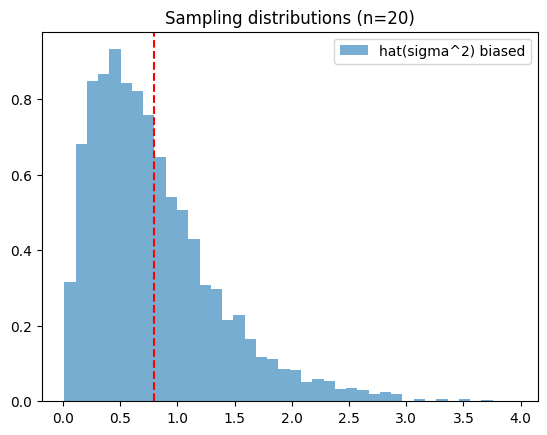

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def simulate_var(n=30, sigma=1.0, reps=10000):
    rng = np.random.default_rng(1)
    hat_var = []
    s2 = []
    for _ in range(reps):
        y = rng.normal(0, sigma, size=n)
        ybar = y.mean()
        hat_var.append(((y - ybar)**2).sum() / n)        # biased
        s2.append(((y - ybar)**2).sum() / (n-1))         # unbiased
    return np.array(hat_var), np.array(s2)

hat_var, s2 = simulate_var(n=5, sigma=1.0, reps=5000)
print("Means (should be ~sigma^2=1):", hat_var.mean(), s2.mean())

plt.hist(hat_var, bins=40, alpha=0.6, label='hat(sigma^2) biased', density=True)
#plt.hist(s2, bins=40, alpha=0.6, label='s^2 unbiased', density=True)
plt.axvline(x=hat_var.mean(), color='red', linestyle='--')
plt.title('Sampling distributions (n=20)'); plt.legend(); plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_means(sample_sizes=(5, 10, 50, 100), reps=10000, seed=1):
    rng = np.random.default_rng(seed)

    results = {}

    for n in sample_sizes:
        # Exponential population with lambda = 1
        # NumPy uses scale = 1/lambda = 1
        samples = rng.exponential(scale=1.0, size=(reps, n))

        # Calculate the sample mean for each of the 10,000 samples
        sample_means = samples.mean(axis=1)

        # Store results
        results[n] = sample_means

    return results


# Run the simulation
results = simulate_means(
    sample_sizes=(5, 10, 50, 100),
    reps=10000,
    seed=1
)


# Print results table
print("Sample size (n) | Empirical mean | Empirical SD")
print("-" * 50)

for n, sample_means in results.items():
    empirical_mean = sample_means.mean()
    empirical_sd = sample_means.std(ddof=1)

    print(f"{n:15d} | {empirical_mean:14.4f} | {empirical_sd:13.4f}")


# Plot the sampling distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (n, sample_means) in zip(axes.ravel(), results.items()):
    ax.hist(
        sample_means,
        bins=40,
        density=True,
        alpha=0.7,
        color="steelblue",
        edgecolor="black"
    )

    # Theoretical mean and standard error
    theoretical_mean = 1
    theoretical_se = 1 / np.sqrt(n)

    ax.axvline(
        theoretical_mean,
        color="red",
        linestyle="--",
        label="Theoretical mean = 1"
    )

    ax.set_title(f"Sampling Distribution of Sample Mean (n={n})")
    ax.set_xlabel("Sample mean")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()
